In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import os
plt.rcParams.update({'font.size': 18})

In [2]:
all_methods =['Nexullance_OPT',
            'Nexullance_MP_APST_4',
            'Nexullance_MP_ASP',
            'Nexullance_IT']

In [3]:
raw_data = {}
for method in all_methods:
    raw_data[method] = pd.read_csv(method+".csv")


In [4]:
raw_data["Nexullance_IT"].head()

,topo,V,D,EPR,traffic,ave_phi,std_phi,ave_time[s],std_time[s],ave_PeakRAM[B],std_PeakRAM[B]
0,DDF,36,5,3,uniform,5.892276,0.0,0.046569,0.000305,193,0.0
1,DDF,36,5,3,shift-half,3.516480,0.0,0.008474,0.000093,193,0.0
2,DDF,36,5,3,nearst-neighbour,9.907408,0.0,0.001630,0.000052,193,0.0
3,DDF,36,5,3,shift-1,10.000000,0.0,0.001683,0.000017,193,0.0
4,DDF,36,5,3,router-cluster,5.683056,0.0,0.023547,0.000242,193,0.0


In [5]:
def plot_for_traffic(traffic_pattern):
    max_V = 100

    # Improved color scheme (colorblind-friendly)
    color_for_method = {
        'Nexullance_OPT': '#fc9d03',  # Orange
        'Nexullance_MP_APST_4': '#03ebfc',  # Sky Blue
        'Nexullance_MP_ASP': '#fc0303',  # Red
        'Nexullance_IT': '#000000'  # Black
    }

    # Improved markers (better differentiation)
    marker_for_topo = {
        'DDF': 'o',  # Circle
        'Slimfly': 's',  # Square
        'Polarfly': 'D',  # Diamond
        'RRG': '^'  # Triangle
    }

    plt.figure(figsize=(8, 6))
    for method in color_for_method.keys():
        data_of_method = raw_data[method]
        data_of_method = data_of_method[data_of_method["traffic"] == traffic_pattern]
        for topo in marker_for_topo.keys():
            data_of_topo = data_of_method[data_of_method["topo"] == topo]
            data_of_topo = data_of_topo[data_of_topo["V"] <= max_V]

            plt.scatter(
                data_of_topo["V"], 
                data_of_topo["ave_time[s]"], 
                label=f"{method} for {topo}",
                color=color_for_method[method], 
                marker=marker_for_topo[topo],
                edgecolors='black'  # Improves visibility in grayscale
            )

    plt.xlabel("S")
    plt.ylabel("ave_time[s]")
    plt.yscale('log')
    plt.title(traffic_pattern)

    # Improved legend for readability
    plt.legend(
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.15),
        fancybox=True, 
        shadow=True, 
        ncol=4  # Reduce columns for better readability
    )

    plt.grid(True, linestyle='--', linewidth=0.5)  # Add grid for clarity
    plt.show()

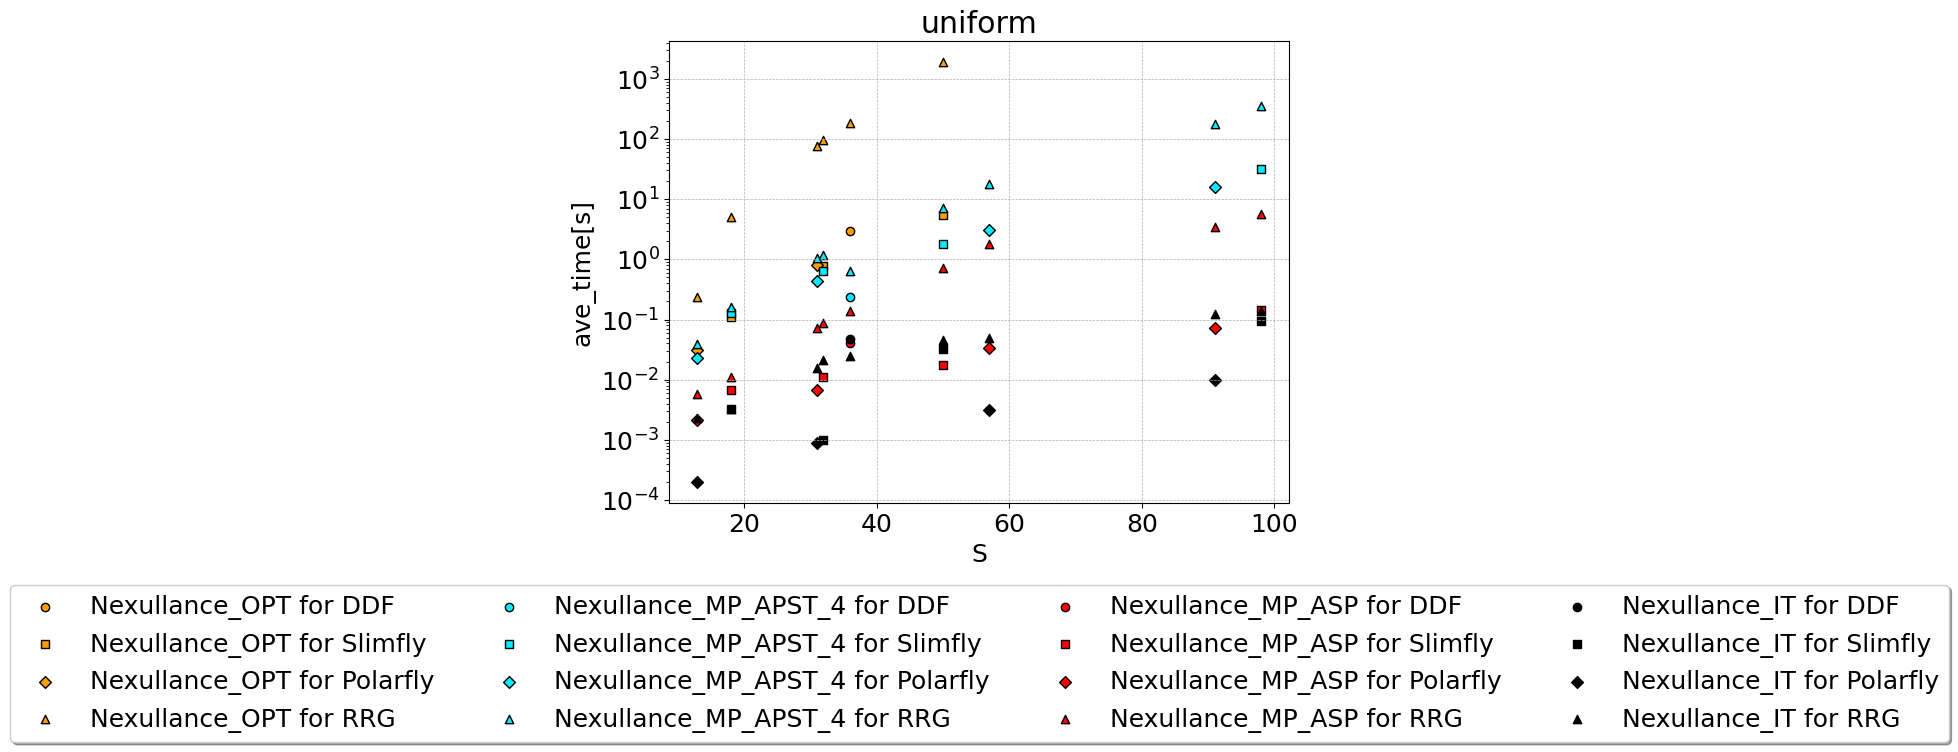

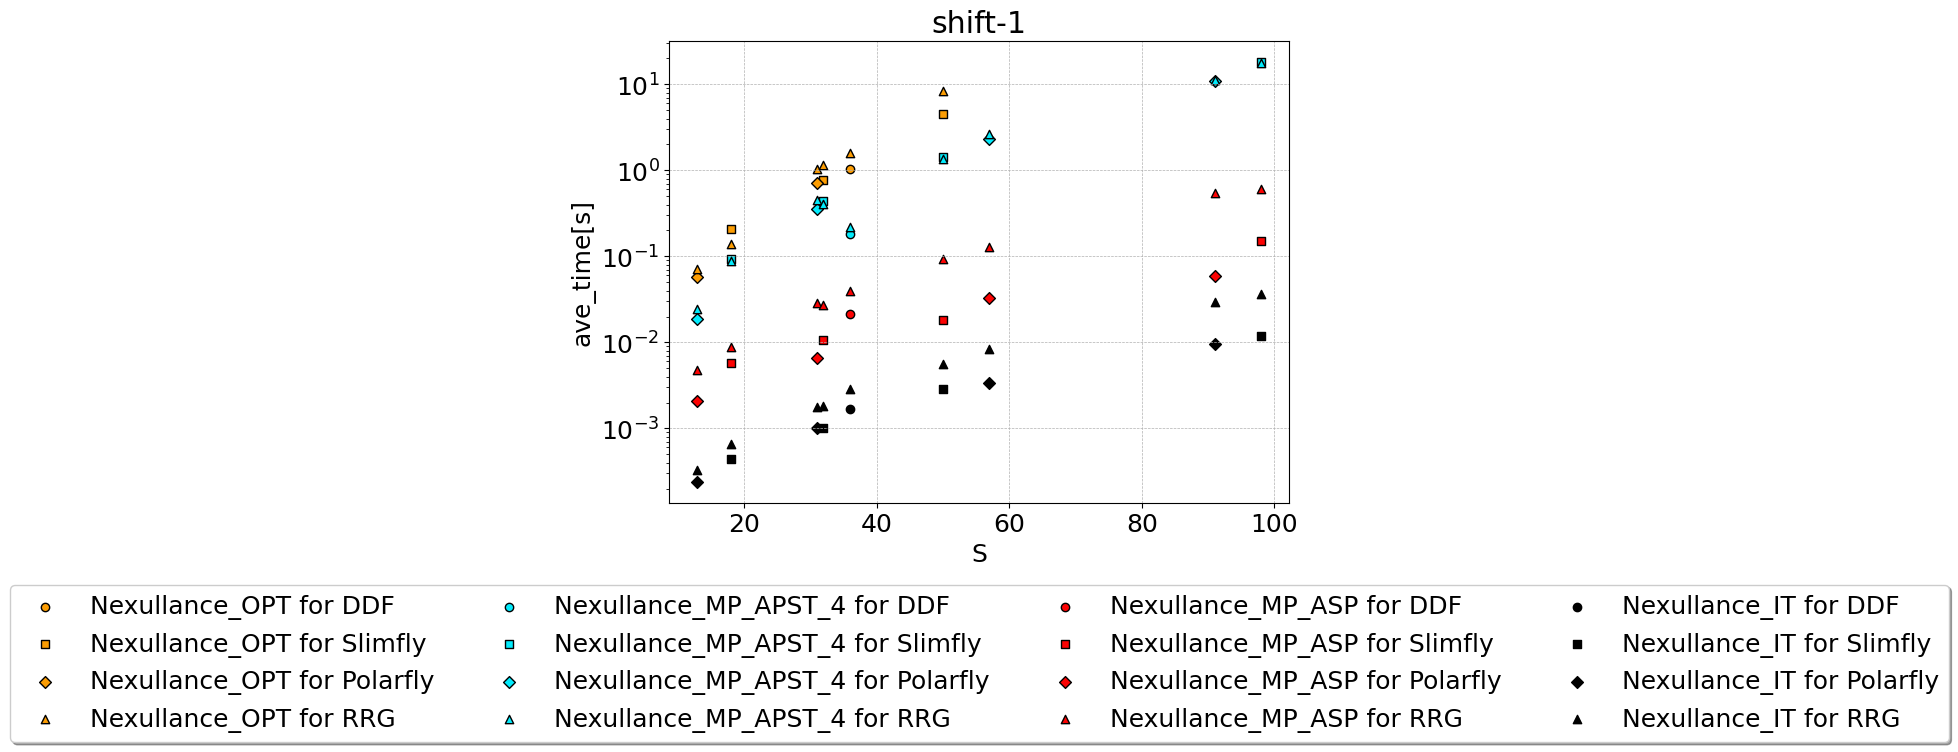

In [6]:
plot_for_traffic('uniform')
plot_for_traffic('shift-1')

In [7]:
def plot_for_method(method, x_power):
    max_V = 100

    # Improved color scheme (colorblind-friendly)
    color_for_traffic = {
        'uniform': '#fc9d03',  # Orange
        'shift-1': '#03ebfc',  # Sky Blue
        'shift-half': '#fc0303',  # Red
        # 'RRG': '#000000'  # Black
    }

    # Improved markers (better differentiation)
    marker_for_topo = {
        'DDF': 'o',  # Circle
        'Slimfly': 's',  # Square
        'Polarfly': 'D',  # Diamond
        'RRG': '^'  # Triangle
    }

    plt.figure(figsize=(12, 8))
    for traffic in color_for_traffic.keys():
        data_of_method = raw_data[method]
        data_of_method = data_of_method[data_of_method["traffic"] == traffic]
        for topo in marker_for_topo.keys():
            data_of_topo = data_of_method[data_of_method["topo"] == topo]
            data_of_topo = data_of_topo[data_of_topo["V"] <= max_V]

            plt.scatter(
                pow(data_of_topo["V"], x_power), 
                data_of_topo["ave_time[s]"], 
                label=f"{traffic} traffic on {topo}",
                color=color_for_traffic[traffic], 
                marker=marker_for_topo[topo],
                edgecolors='black'  # Improves visibility in grayscale
            )

    plt.xlabel(f"S^{x_power}")
    plt.ylabel("ave_time[s]")
    plt.title(method)

    # Improved legend for readability
    plt.legend(
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.15),
        fancybox=True, 
        shadow=True, 
        ncol=3  # Reduce columns for better readability
    )

    plt.grid(True, linestyle='--', linewidth=0.5)  # Add grid for clarity
    plt.show()

In [8]:

plt.rcParams.update({'font.size': 22})

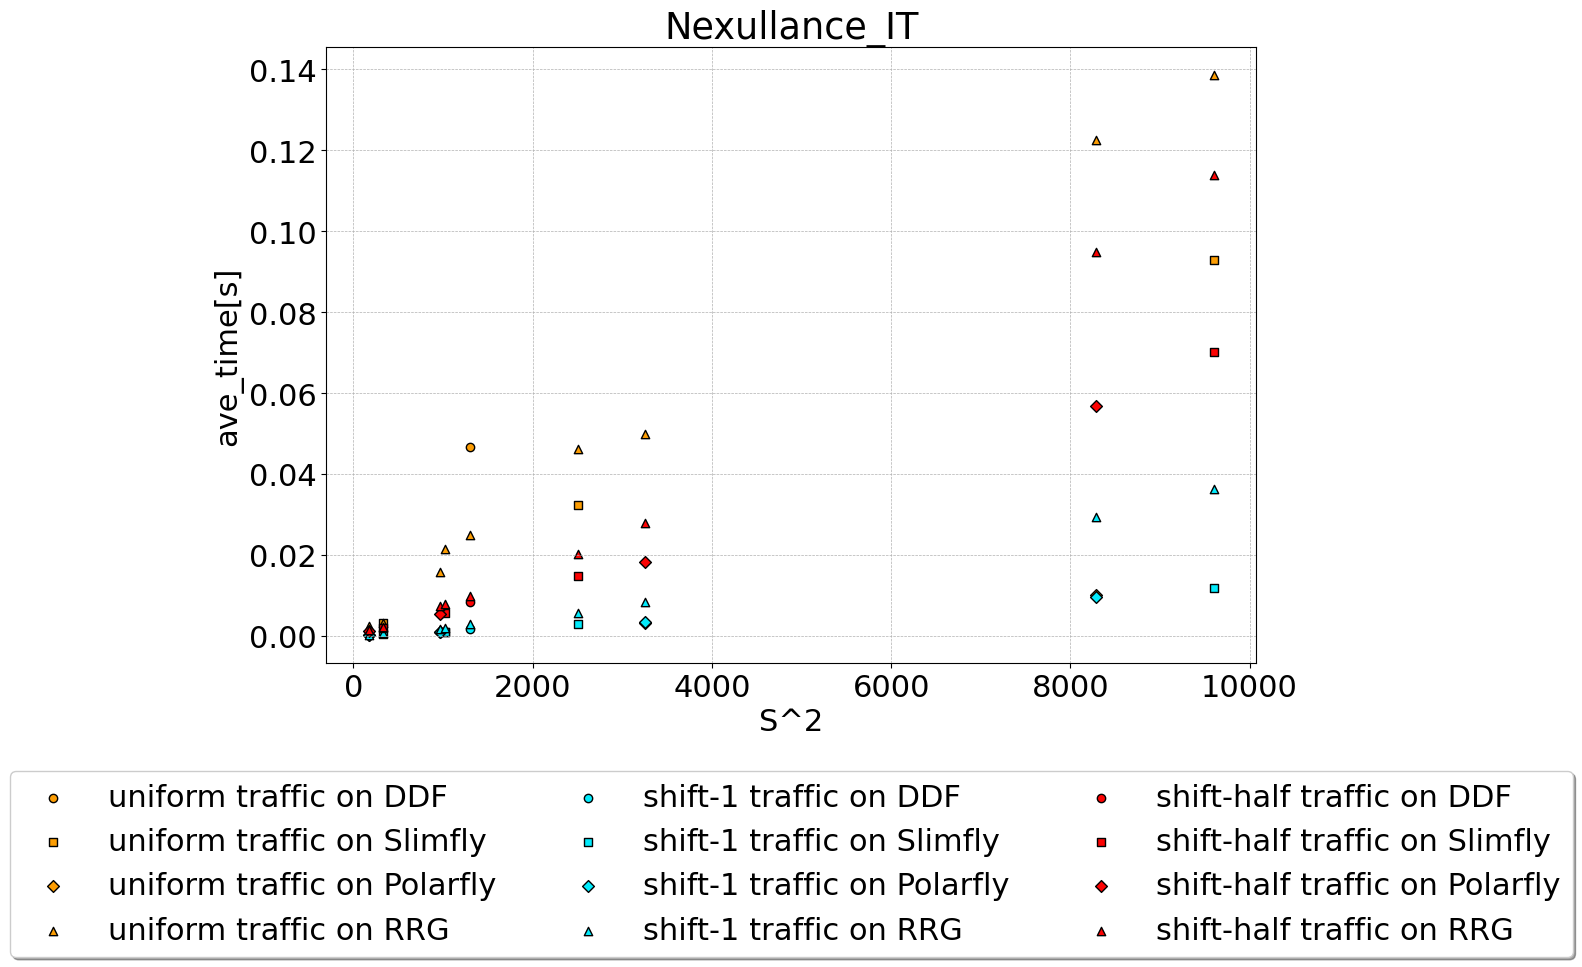

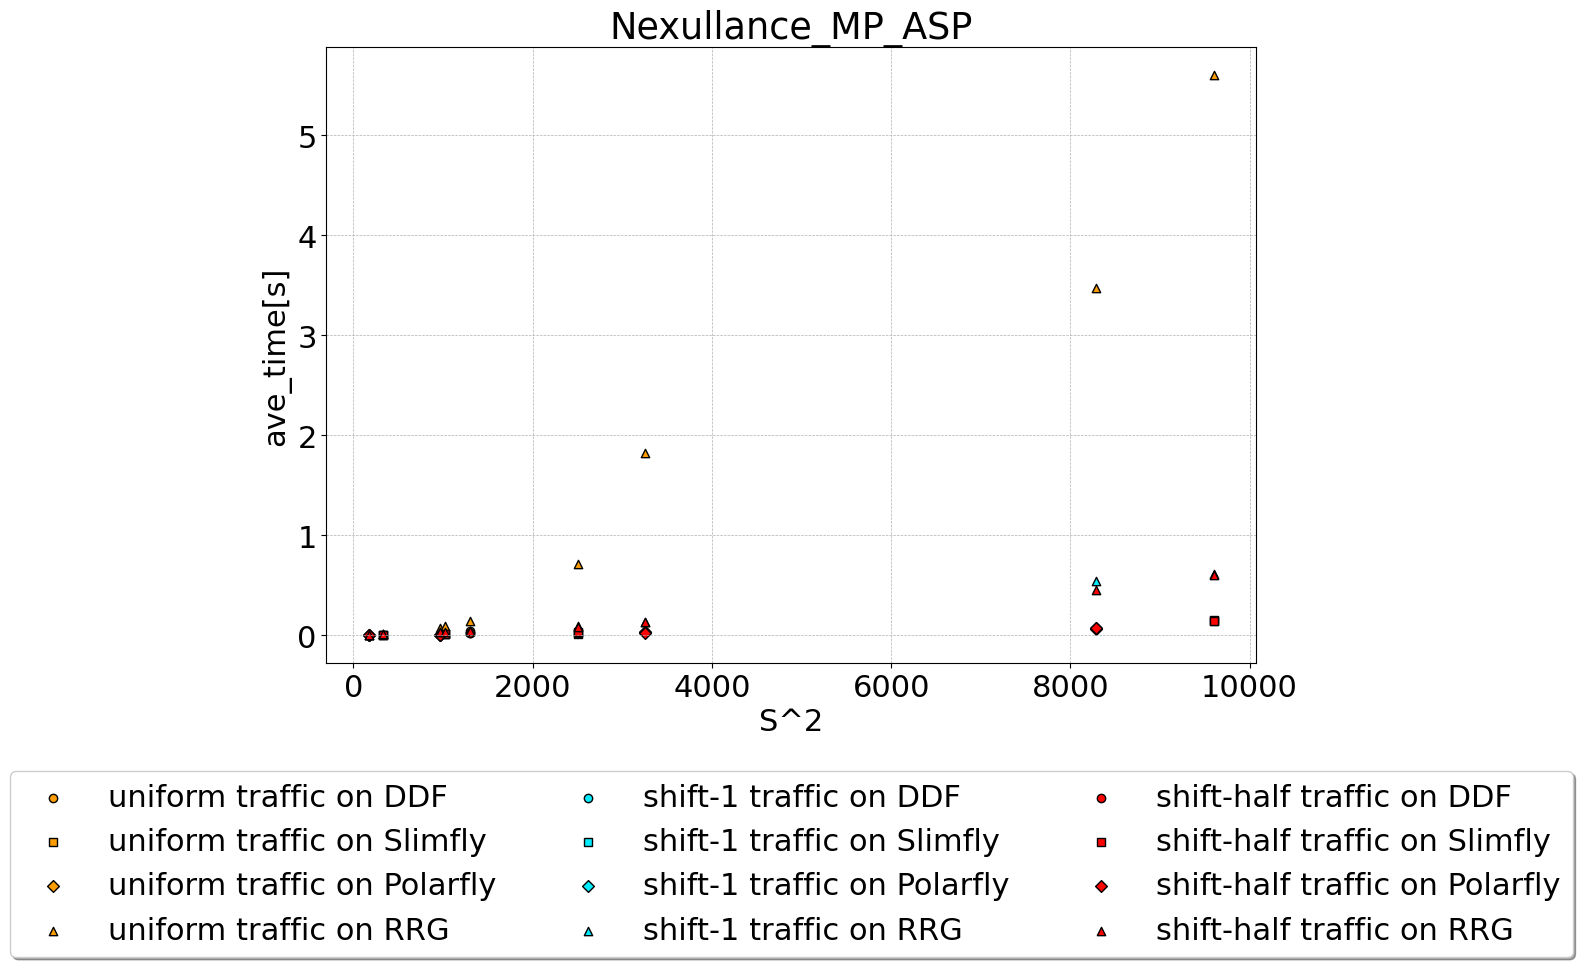

In [9]:
plot_for_method("Nexullance_IT", 2)
plot_for_method("Nexullance_MP_ASP", 2)
# plot_for_method("Nexullance_MP_APST_4", 5)